In [24]:
import pandas as pd
import re
from sklearn.utils import resample
import matplotlib.pyplot as plt

# =========================
# 1) Load dataset
# =========================
FILE_PATH = r"C:\Users\hp\Downloads\SaudiBERT\مجموع الشكاوي تحديث.xlsx"
TEXT_COL = "نص الشكوى"
LABEL_COL = "الجهة"

df = pd.read_excel(FILE_PATH)

# =========================
# 2) Text cleaning function (Light preprocessing suitable for BERT models)
# =========================
def full_clean(text):
    if not isinstance(text, str):
        return ""

    # Remove Saudi phone numbers (05xxxxxxxx)
    text = re.sub(r'\b05\d{8}\b', ' ', text)

    # Remove dates (e.g., 12/02/2024)
    text = re.sub(r'\b\d{1,2}/\d{1,2}/\d{2,4}\b', ' ', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove mentions and hashtags
    text = re.sub(r'[#@]\S+', ' ', text)

    # Remove Arabic diacritics
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)

    # Keep only Arabic characters and digits
    # (digits are preserved since order numbers or invoice IDs may be informative)
    text = re.sub(r'[^\u0600-\u06FF0-9\s]', ' ', text)

    # Reduce excessive character repetition (e.g., جمييييل → جمييل)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# =========================
# 3) Remove rows with missing complaint text or label
# =========================
df = df.dropna(subset=[TEXT_COL, LABEL_COL]).copy()

# =========================
# 4) Apply text cleaning
# =========================
df["clean_text"] = df[TEXT_COL].apply(full_clean)

# =========================
# 5) Remove very short complaints (likely noisy or non-informative)
# =========================
df = df[df["clean_text"].str.len() > 5].copy()

# =========================
# 6) Remove duplicate complaints after cleaning
# =========================
df = df.drop_duplicates(subset=["clean_text"]).reset_index(drop=True)

# =========================
# 7) Inspect class distribution before balancing
# =========================
print("Before balancing shape:", df.shape)

# Display the number of samples per authority (class)
print("Before balancing label counts:\n", df[LABEL_COL].value_counts())

Before balancing shape: (6644, 3)
Before balancing label counts:
 الجهة
وزارة الحج والعمرة                550
الهيئة العامة للنقل               549
الجرائم المعلوماتية (كلنا أمن)    549
وزارة التعليم                     547
وزارة البيئة                      546
الاحوال المدينة                   545
مكافحة مخدرات                     535
وزارة التجارة                     512
شركة الكهرباء السعودية            495
بلدي                              466
وزارة الصحة                       466
وزارة الرياضة                     447
شركة الاتصالات السعودية           437
Name: count, dtype: int64


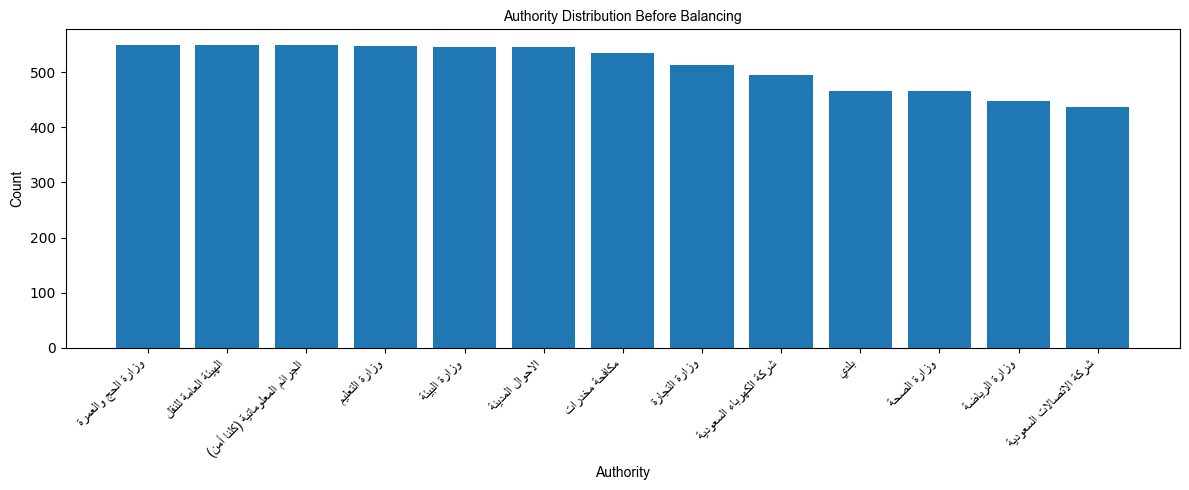

In [25]:
import matplotlib.pyplot as plt
import arabic_reshaper
from bidi.algorithm import get_display
from matplotlib import font_manager as fm

FONT_PATH = r"C:\Windows\Fonts\arial.ttf"   
arabic_font = fm.FontProperties(fname=FONT_PATH)

# Function to properly render Arabic text in matplotlib
def fix_ar(text):
    reshaped = arabic_reshaper.reshape(str(text))
    return get_display(reshaped)

# Compute label distribution
label_counts = df[LABEL_COL].value_counts()

# Fix Arabic labels for correct RTL display
fixed_labels = [fix_ar(label) for label in label_counts.index]

# Create bar chart
plt.figure(figsize=(12,5))
plt.bar(fixed_labels, label_counts.values)

# Set plot titles and axis labels (English for academic consistency)
plt.title("Authority Distribution Before Balancing", fontproperties=arabic_font)
plt.xlabel("Authority", fontproperties=arabic_font)
plt.ylabel("Count", fontproperties=arabic_font)

plt.xticks(rotation=45, ha="right", fontproperties=arabic_font)
plt.tight_layout()
plt.show()

In [26]:
# =========================
# 8) UNDER-SAMPLING — Balance classes by reducing to the smallest class size
# =========================
def undersample_balance(data: pd.DataFrame, label_col: str, random_state: int = 42) -> pd.DataFrame:
    
    # Compute the number of samples per class
    counts = data[label_col].value_counts()
    
    # Identify the smallest class size
    min_count = counts.min()

    balanced_parts = []
    
    # For each class, randomly downsample to the minimum class size
    for label, cnt in counts.items():
        part = data[data[label_col] == label]
        
        part_down = resample(
            part,
            replace=False,        # No replacement (true downsampling)
            n_samples=min_count,  # Reduce to smallest class size
            random_state=random_state
        )
        
        balanced_parts.append(part_down)

    # Concatenate all balanced subsets
    balanced_df = pd.concat(balanced_parts, ignore_index=True)
    
    # Shuffle the final balanced dataset
    balanced_df = balanced_df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    return balanced_df


# Apply under-sampling to create a balanced dataset
df_balanced = undersample_balance(df, LABEL_COL)




After balancing dataset shape: (5681, 3)
After balancing label counts:
 الجهة
الجرائم المعلوماتية (كلنا أمن)    437
وزارة البيئة                      437
شركة الكهرباء السعودية            437
وزارة الرياضة                     437
مكافحة مخدرات                     437
وزارة التعليم                     437
الاحوال المدينة                   437
الهيئة العامة للنقل               437
وزارة الصحة                       437
بلدي                              437
وزارة الحج والعمرة                437
وزارة التجارة                     437
شركة الاتصالات السعودية           437
Name: count, dtype: int64


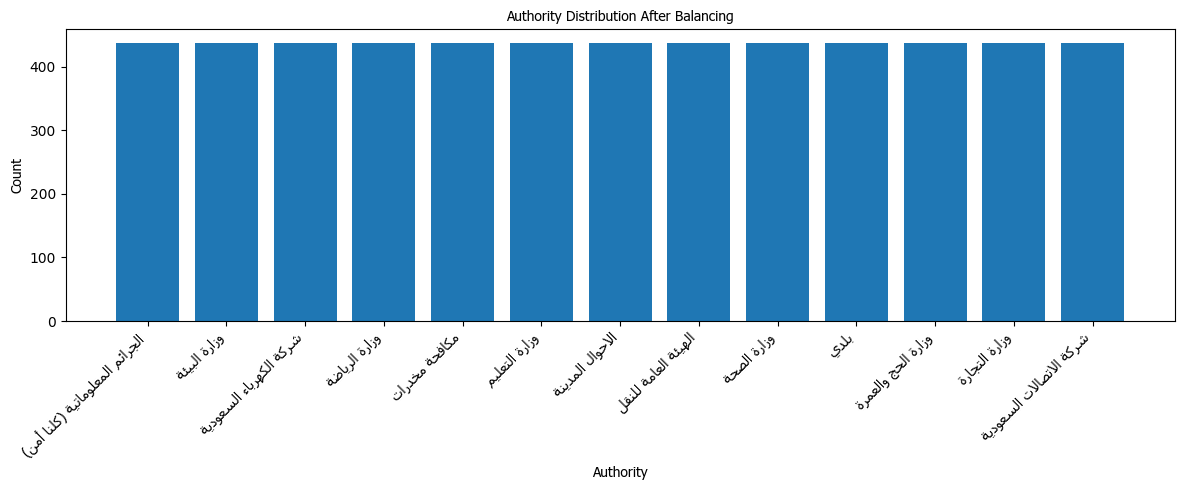


Balanced dataset saved to: complaints_clean_balanced_under.xlsx


In [27]:
FONT_PATH = r"C:\Windows\Fonts\tahoma.ttf"
arabic_font = fm.FontProperties(fname=FONT_PATH)

# Function to correctly render Arabic text in matplotlib
def fix_ar(text):
    reshaped = arabic_reshaper.reshape(str(text))
    return get_display(reshaped)

# =========================
# 9) Inspect distribution after balancing
# =========================
after_counts = df_balanced[LABEL_COL].value_counts()

print("\nAfter balancing dataset shape:", df_balanced.shape)
print("After balancing label counts:\n", after_counts)

# Fix Arabic class names for proper RTL visualization
fixed_labels = [fix_ar(label) for label in after_counts.index]

plt.figure(figsize=(12,5))
plt.bar(fixed_labels, after_counts.values)

plt.title("Authority Distribution After Balancing", fontproperties=arabic_font)
plt.xlabel("Authority", fontproperties=arabic_font)
plt.ylabel("Count", fontproperties=arabic_font)

plt.xticks(rotation=45, ha="right", fontproperties=arabic_font)
plt.tight_layout()
plt.show()

# =========================
# 10) Save final balanced dataset
# =========================
OUT_PATH = "complaints_clean_balanced_under.xlsx"
df_balanced.to_excel(OUT_PATH, index=False)

print(f"\nBalanced dataset saved to: {OUT_PATH}")